In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torchvision import models
from torchinfo import summary
from Going_Modular.Data_Setup import create_dataloaders
from Going_Modular.Train import train
from Going_Modular.Test import testing_pipeline
from Going_Modular.Predict_Custom_Image import predict_custom_image

In [2]:
train_dir="pizza_steak_sushi/train"
test_dir="pizza_steak_sushi/test"

In [3]:
common_transform=transforms.Compose([transforms.Resize((224,224)),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                         std=[0.229, 0.224, 0.225])
                                    ])

In [4]:
train_dataloader,test_dataloader,class_names=create_dataloaders(train_dir,
                                                                test_dir,
                                                                common_transform,
                                                                common_transform,
                                                                8)

In [5]:
train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x12a32b496a0>,
 ['pizza', 'steak', 'sushi'])

In [6]:
len(train_dataloader),len(test_dataloader)

(29, 10)

In [7]:
img,label=next(iter(train_dataloader))

In [8]:
img[0].shape,label.shape

(torch.Size([3, 224, 224]), torch.Size([8]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


Text(0.5, 1.0, 'steak')

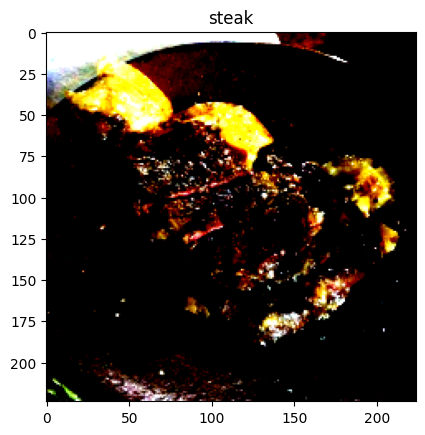

In [9]:
plt.imshow(img[0].permute(1,2,0))
plt.title(class_names[label[0]])

In [10]:
weights=models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [11]:
auto_transform=weights.transforms()
auto_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [12]:
model=models.efficientnet_b0(weights=weights)

In [13]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [14]:
summary(model,input_size=(8,3,224,224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [8, 1000]                 --
├─Sequential: 1-1                                       [8, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [8, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [8, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                            [8, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                   [8, 32, 112, 112]         --
│    └─Sequential: 2-2                                  [8, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                 [8, 16, 112, 112]         1,448
│    └─Sequential: 2-3                                  [8, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                 [8, 24, 56, 56]           6,004
│    │    └─MBConv: 3-6                              

In [15]:
for param in model.features.parameters():
    param.requires_grad=False

In [16]:
output_shape=len(class_names)
model.classifier=nn.Sequential(
    nn.Dropout(p=0.2,
               inplace=True),
    nn.Linear(in_features=1280,
              out_features=output_shape,
              bias=True)
)

In [17]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [18]:
summary(model,(8,3,224,224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [8, 3]                    --
├─Sequential: 1-1                                       [8, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [8, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [8, 32, 112, 112]         (864)
│    │    └─BatchNorm2d: 3-2                            [8, 32, 112, 112]         (64)
│    │    └─SiLU: 3-3                                   [8, 32, 112, 112]         --
│    └─Sequential: 2-2                                  [8, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                 [8, 16, 112, 112]         (1,448)
│    └─Sequential: 2-3                                  [8, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                 [8, 24, 56, 56]           (6,004)
│    │    └─MBConv: 3-6                      

In [19]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=0.0001)

In [20]:
train(model,train_dataloader,optimizer,loss_func,6)

  0%|          | 0/6 [00:00<?, ?it/s]

-----Epoch 1-----
Training loss is 1.007574634305362
Training accuracy is 0.45689655172413796
-----Epoch 2-----
Training loss is 0.7130810649230562
Training accuracy is 0.8146551724137931
-----Epoch 3-----
Training loss is 0.6015479626326725
Training accuracy is 0.7844827586206896
-----Epoch 4-----
Training loss is 0.515662342823785
Training accuracy is 0.8362068965517241
-----Epoch 5-----
Training loss is 0.4738686829805374
Training accuracy is 0.8362068965517241
-----Epoch 6-----
Training loss is 0.4719834594890989
Training accuracy is 0.8577586206896551
Time taken for training is 62.84634969999934.


In [21]:
model_result=testing_pipeline(model,test_dataloader,loss_func)
model_result

{'model_name': 'EfficientNet',
 'model_loss': 0.382081013917923,
 'model_acc': 0.9375}

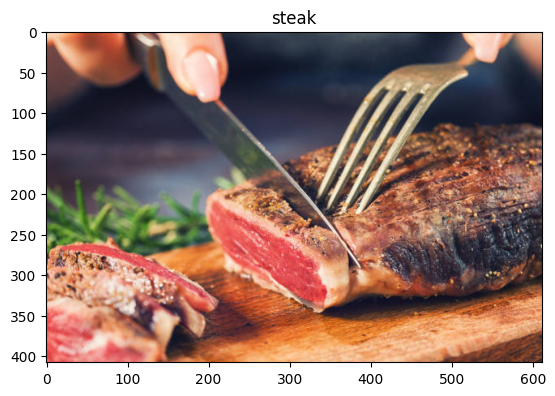

In [24]:
predict_custom_image("Steak.jpg",model,auto_transform,class_names)

In [25]:
test_data=datasets.ImageFolder(test_dir,auto_transform)

In [26]:
labels=test_data.targets

In [27]:
predictions=[]

In [28]:
model.eval()
with torch.inference_mode():
    for image,label in test_data:
        pred=model(image.unsqueeze(0)).argmax(dim=1)
        predictions.append(pred.item())

In [29]:
cm=confusion_matrix(labels,predictions)
cm

array([[22,  0,  3],
       [ 0, 15,  4],
       [ 3,  2, 26]])

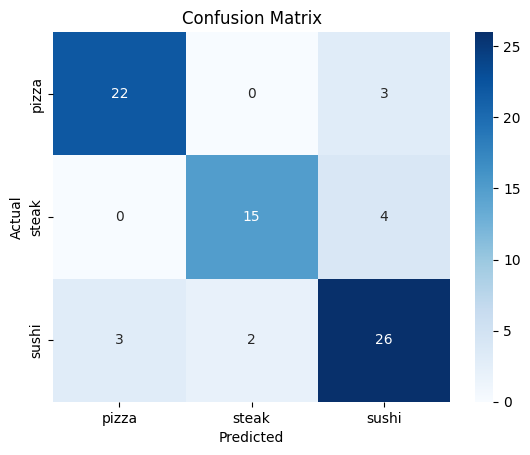

In [30]:
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()